In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sparse_methods import matricies
from sampling import samp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]

## Sparse systems in algorithms

In linear algebra, we come accross many problems or calcuations which are computationally expensive ($O(n^{3})$ just for naive matrix multiplication). But, what we also come across in linear algebra is systems where most coefficients are zero. These two things combined mean that computers can spend a lot of time multiplying numbers by zeros in computations (which will always result in another zero). Knowing this, we are able to take advantage of the sparseness of systems/matricies to make computations faster.

Take the example problem: solve $Ax = b$ for $\text{sparse } A \in \mathbb{R}^{N \times N}$ and $b = \begin{bmatrix} 1 & 1 & \cdots & 1\end{bmatrix}^{T}$, with $N = 2^{10} = 1024$, and then to find the dominant eigenvalue of that same $A$.

For this instance, we will generate $A$ at random to be a sparse diagonally-dominant matrix. Each off-diagonal entry is

$$A_{ij} = \begin{cases} U(-1, 1) & \text{with probability } N^{-2/3} \\ 0 & \text{otherwise} \end{cases}$$

so a row picks up $N \times N^{-2/3} = N^{1/3} \approx 10$ nonzero off-diagonal entries out of the 1023 slots available to it. The diagonal is then set to

$$A_{ii} = \sum_{j \neq i} |A_{ij}| + 1$$

Diagonal entries are always at least 1, so the matrix has no empty rows, and every row is strictly diagonally dominant, which then guarentees convergance of the Jacobi method to solve this problem (though sparseness can help for many other algorithms).

In [2]:
n = 2**10

A = matricies.construct_random_sparse(n)
b = np.ones(n)

diag = A.diagonal()
row_sums = np.abs(A).sum(1) - diag
off_diagonal = np.count_nonzero(A) - n

print(f"N = {n}")
print(f"nonzero off-diagonal entries: {off_diagonal}, or {off_diagonal / n:.2f} per row (expected {n**(1/3):.2f})")
print(f"density: {100 * np.count_nonzero(A) / n**2:.2f}%")
print(f"strictly diagonally dominant: {bool(np.all(diag > row_sums))}")

N = 1024
nonzero off-diagonal entries: 10210, or 9.97 per row (expected 10.08)
density: 1.07%
strictly diagonally dominant: True


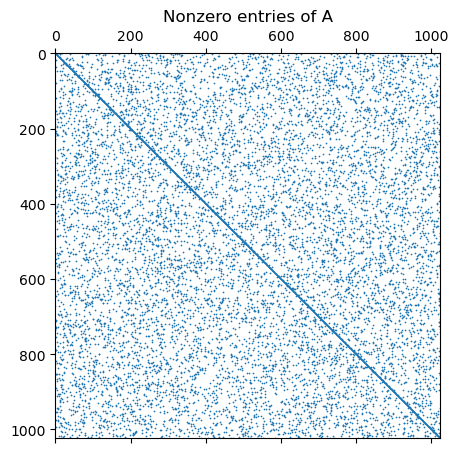

In [3]:
plt.figure(figsize = (5, 5))
plt.spy(A, markersize = 0.3)
plt.title("Nonzero entries of A")
plt.show()

### The Jacobi iteration

Split $A$ into its diagonal $D$ and everything else $R$, so that $A = D + R$. Then solve

$$Ax = b \implies Dx = b - Rx \implies x = D^{-1}(b - Rx)$$

which is a fixed point equation, $x = g(x)$. Guess an $x^{(0)}$ and iterate:

$$x^{(k + 1)} = D^{-1}\left(b - Rx^{(k)}\right)$$

Or elementwise, equivalently:

$$x^{(k+1)}_{i} = \frac{1}{A_{ii}}\left(b_{i} - \sum_{j \neq i} A_{ij}x^{(k)}_{j}\right)$$

Every component of the new vector reads only from the previous one, which is what separates Jacobi from Gauss-Seidel; each step is a single matrix-vector product plus a divide.

Subtracting the fixed point equation from the iteration gives $e^{(k+1)} = -D^{-1}Re^{(k)}$ for the error $e^{(k)} = x^{(k)} - x$, so the method converges from any starting vector iff the spectral radius (maximum $|\lambda|$) of $-D^{-1}R$ is below 1. Strict diagonal dominance is enough to guarantee that, since:

$$\rho(D^{-1}R) \leq \max_{i} \frac{\sum_{j \neq i}|A_{ij}|}{|A_{ii}|} = \max_{i} \frac{s_{i}}{s_{i} + 1} < 1$$

writing $s_i$ for the row sum the diagonal was built from.

This implementation starts at $x^{(0)} = 0$ and stops once $\|x^{(k)} - x^{(k-1)}\|_{2} < 10^{-4}$ or $\|Ax^{(k)} - b\|_{2} < 10^{-4}$. 

```python
def jacobi(A, b, x):
    next = (b - (A @ x - diag * x)) / diag

    if norm(next - x) < error or norm(A @ next - b) < error:
        return next

    return jacobi(A, b, next)
```

The residual test needs a product of its own, so an iteration is really two matrix-vector products. It shows up in the timings later.

Solving a 6 by 6 system first, with NumPy's direct solver alongside as a check:

In [39]:
small = matricies.construct_random_sparse(6)
small_b = np.ones(6)

print("jacobi:      ", np.round(matricies.jacobi_dense(small, small_b), 4))
print("numpy solve: ", np.round(np.linalg.solve(small, small_b), 4))

jacobi:       [0.2121 0.4466 0.3159 0.8495 0.6358 0.7217]
numpy solve:  [0.212  0.4466 0.3159 0.8495 0.6358 0.7217]


Using what we know about the error, and how it relates to spectral radius, we can calculate how fast we expect Jacobi to converge.

In [5]:
bound = np.max(row_sums / diag)
radius = np.max(np.abs(np.linalg.eigvals(-(A - np.diag(diag)) / diag[:, None])))

print(f"worst row ratio, the dominance bound: {bound:.4f}")
print(f"spectral radius of -D^-1 R:           {radius:.4f}")
print(f"so the residual should fall by about {1 / radius:.1f}x per iteration")

worst row ratio, the dominance bound: 0.9249
spectral radius of -D^-1 R:           0.3188
so the residual should fall by about 3.1x per iteration


This is much smaller than 1 (on average), since the signed values largely cancel each other out.

### Coordinate format

Storing $A$ densely means $1024^2 \approx 1.05$ million floats to hold $1024^{4/3} + 1024 \approx 11$ thousand real entries, and worse, meaning the product $Ax$ spends 99% of its multiplications on zeros. Coordinate format stores only what is there: three parallel arrays holding the row index, the column index and the value of each nonzero entry, so that `vals[k] = A[coords[0][k]][coords[1][k]]`.
$$
  \begin{bmatrix}
    0 & 8 & 0 \\
    1 & 0 & 0 \\
    0 & 6 & 7
  \end{bmatrix}

  \rightarrow

  \begin{array}{c | cccc}
  i & 0 & 1 & 2 & 2 \\
  j & 1 & 0 & 1 & 2 \\
  \hline
  \text{val} & 8 & 1 & 6 & 7
  \end{array}
$$
`get_coo` in `matricies` searches the matrix row by row, so the triplets come out sorted by row then column index. That ordering is which lets `coo_matvec` (coo matrix vector multiplication) sweep the arrays with a single pointer, filling one output entry at a time.

In [43]:
coords, vals = matricies.get_coo(small)

print(np.round(small, 3), "\n")
print("rows:", coords[0])
print("cols:", coords[1])
print("vals:", np.round(vals, 3))
print(f"\n{len(vals)} stored entries against {small.size} in the dense array")

[[ 1.845  0.188  0.     0.503  0.154  0.   ]
 [ 0.     1.474  0.     0.     0.     0.474]
 [ 0.079 -0.305  2.101  0.     0.717  0.   ]
 [ 0.    -0.016  0.     1.69  -0.675  0.   ]
 [ 0.     0.     0.367 -0.652  2.133  0.114]
 [ 0.    -0.862  0.    -0.144 -0.692  2.698]] 

rows: [0 0 0 0 1 1 2 2 2 2 3 3 3 4 4 4 4 5 5 5 5]
cols: [0 1 3 4 1 5 0 1 2 4 1 3 4 2 3 4 5 1 3 4 5]
vals: [ 1.845  0.188  0.503  0.154  1.474  0.474  0.079 -0.305  2.101  0.717
 -0.016  1.69  -0.675  0.367 -0.652  2.133  0.114 -0.862 -0.144 -0.692
  2.698]

21 stored entries against 36 in the dense array


The dense product costs $n^2$ time no matter what is in the matrix. The COO product costs one per stored entry, which here is $n + n^{4/3} \approx 11{,}300$ against $1{,}048{,}576$, a factor of about 92 fewer.

Conversion is not free: `get_coo` scans all $n^2$ entries to find the nonzeros, which costs about as much as one dense product. But since happens once, outside the iteration loop, it pays off quickly. And in a real application you would assemble the matrix in COO directly and never build the dense copy at all.

Running both implementations on the same system and comparing:

In [49]:
dense_jacobi = {"errors": [], "times": []}
coo_jacobi = {"errors": [], "times": []}

x_dense = matricies.jacobi_dense(A, b, history = dense_jacobi)
x_coo = matricies.jacobi_coo(A, b, history = coo_jacobi)

for name, history in (("dense", dense_jacobi), ("COO  ", coo_jacobi)):
    iterations = len(history["errors"])
    print(f"{name}: {iterations} iterations, {history['times'][-1]:8.1f} ms total, "
          f"{history['times'][-1] / iterations:6.1f} ms per iteration, "
          f"final ||Ax - b||_2 = {history['errors'][-1]:.3e}")

print(f"\nspeedup: {dense_jacobi['times'][-1] / coo_jacobi['times'][-1]:.1f}x")
print(f"identical iterates: {np.array_equal(x_dense, x_coo)}")
print(f"x range [{x_coo.min():.6f}, {x_coo.max():.6f}], mean {x_coo.mean():.6f}")

dense: 11 iterations,   7397.2 ms total,  672.5 ms per iteration, final ||Ax - b||_2 = 8.946e-05
COO  : 11 iterations,    225.7 ms total,   20.5 ms per iteration, final ||Ax - b||_2 = 8.946e-05

speedup: 32.8x
identical iterates: True
x range [-0.039294, 0.590253], mean 0.182188


The iterates, number of iterations, and error will always be the same (decreasing exactly by the factor calculated above), since we are performing the exact same algorithm, just computed differently.

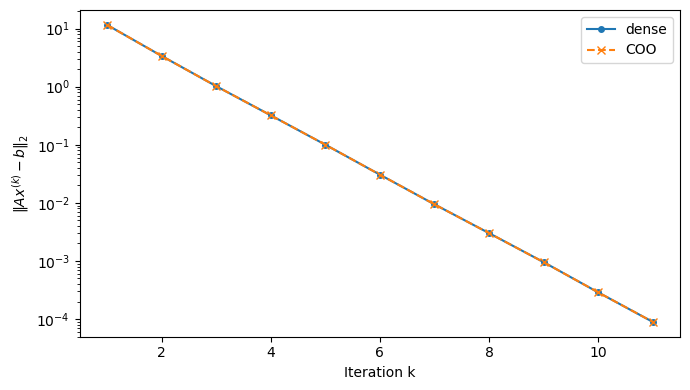

In [45]:
dense_k = np.arange(1, len(dense_jacobi["errors"]) + 1)
coo_k = np.arange(1, len(coo_jacobi["errors"]) + 1)

fig, ax = plt.subplots(figsize = (7, 4))

# The curves coincide exactly, so the COO line is dashed to keep both visible
ax.plot(dense_k, dense_jacobi["errors"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_jacobi["errors"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

ax.set_yscale("log")
ax.set_xlabel("Iteration k")
ax.set_ylabel(r"$\|Ax^{(k)} - b\|_2$")
ax.legend()

plt.tight_layout()
plt.show()

But the Jacobian algorithm will run orders of magnitude quicker.

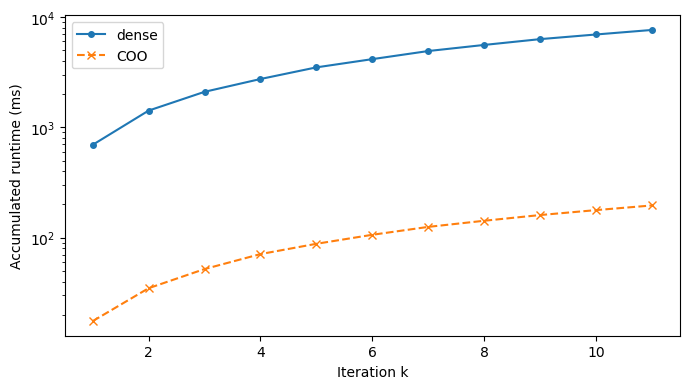

In [46]:
fig, ax = plt.subplots(figsize = (7, 4))

ax.plot(dense_k, dense_jacobi["times"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_jacobi["times"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

# Log scale, otherwise the COO curve is pinned to the axis and unreadable next to dense
ax.set_yscale("log")
ax.set_xlabel("Iteration k")
ax.set_ylabel("Accumulated runtime (ms)")
ax.legend()

plt.tight_layout()
plt.show()

This discrepency is truer the greater the size (sparsity) of the matrix (as COO in this instance scales with $~n^{4/3}$, and naive with $~n^2$)

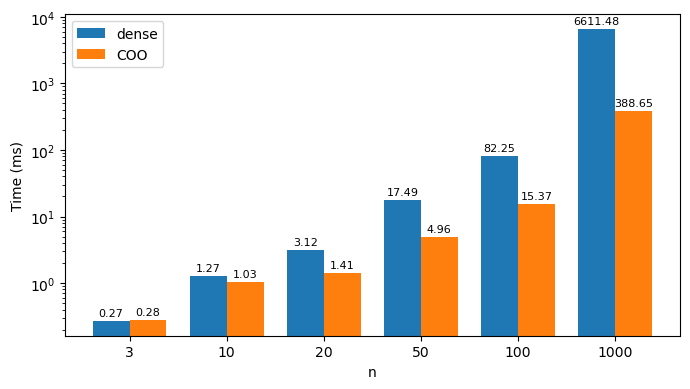

In [48]:
testcases = (3, 10, 20, 50, 100, 1_000)

matricies.scaling_jacobian(testcases, error = False, runs = 5)

And a 

It is worth noting that the COO approach is only ~30x faster, and not the 90x we calculated from before, based on operation count. Timing the products, COO costs about 2.7 times more per stored entry than the dense version costs per entry. This is because for each entry, we call the $i$ cordinate, $j$ coordinate, and the value, instead of just the value (from counting linearly in the dense approach).

### The power method

For the dominant eigenvalue, write any starting vector in the eigenbasis of $A$, assuming that one exists:

$$v^{(0)} = c_{1}u_{1} + c_{2}u_{2} + \dots + c_{n}u_{n}$$

Applying $A$ repeatedly scales each term by its own eigenvalue, so

$$A^{k}v^{(0)} = \left(c_{1}u_{1}\lambda_{1}^k + c_{2}u_{2}\lambda_{2}^{k} + \dots\right)$$

If $|\lambda_1|$ is the largest eigenvalue, every other $|\frac{\lambda_{i}}{\lambda_{1}}|^{k}$ shrinks, and all vectors except the $u_1$ term decays. $A^k v^{(0)}$ therefore tends to the dominant eigenvector, and the error shrinks at about $|\lambda_2 / \lambda_1|^k$.

Finding the vector iterivly, we can put it in the form:

$$v^{(k+1)} = \frac{Av^{(k)}}{\left\|Av^{(k)}\right\|_{2}}$$

With $v$ normalized, the Rayleigh quotient for the eigenvalue simplifies:

$$\lambda^{(k)} = \frac{v^{(k)T}Av^{(k)}}{||v^{k}||^2} = v^{(k)T}\left(Av^{(k)}\right)$$

The denominator is 1 and we already have $Av^{(k)}$ from the normalization step, so the estimate is just a dot product, $O(n)$ against the $O(n^2)$ or $O(u \cdot n)$ of the product itself.

Starting from $v^{(0)} = \frac{1}{\sqrt{N}}\begin{bmatrix}1 & 1 & \cdots & 1\end{bmatrix}^{T}$, which is normalized already, and stopping at $\|v^{(k)} - v^{(k-1)}\|_2 < 10^{-4}$:

```python
def power(A, v):
    av = A @ v
    lam = v @ av
    next = av / norm(av)

    if norm(next - v) < error:
        return lam, next

    return power(A, next)
```

Unlike Jacobi there is one product per iteration rather than two, since the convergence test looks at the vector iself rather than a residual.

In [10]:
dense_power = {"eigenvalues": [], "times": []}
coo_power = {"eigenvalues": [], "times": []}

lam_dense, v_dense = matricies.power_method_dense(A, history = dense_power)
lam_coo, v_coo = matricies.power_method_coo(A, history = coo_power)

for name, history in (("dense", dense_power), ("COO  ", coo_power)):
    iterations = len(history["eigenvalues"])
    print(f"{name}: {iterations} iterations, {history['times'][-1]:8.1f} ms total, "
          f"{history['times'][-1] / iterations:6.1f} ms per iteration")

print(f"\nspeedup: {dense_power['times'][-1] / coo_power['times'][-1]:.1f}x")
print(f"identical iterates: {np.array_equal(v_dense, v_coo)}")
print()
print(f"dominant eigenvalue: {lam_coo:.6f}")
print(f"||Av - (lambda)v||_2 = {np.linalg.norm(A @ v_coo - lam_coo * v_coo):.3e}")
print(f"||v||_2 = {np.linalg.norm(v_coo):.6f}, v range [{v_coo.min():.6f}, {v_coo.max():.6f}]")

eigenvalues = np.linalg.eigvals(A)
dominant = eigenvalues[np.abs(eigenvalues).argmax()].real
print(f"\nnumpy check: largest |eigenvalue| = {dominant:.6f}, second = "
      f"{np.sort(np.abs(eigenvalues))[-2]:.6f}, ratio = {np.sort(np.abs(eigenvalues))[-2] / abs(dominant):.4f}")

dense: 289 iterations,  97075.1 ms total,  335.9 ms per iteration
COO  : 289 iterations,   2694.9 ms total,    9.3 ms per iteration

speedup: 36.0x
identical iterates: True

dominant eigenvalue: 13.295161
||Av - (lambda)v||_2 = 1.292e-03
||v||_2 = 1.000000, v range [-0.509541, 0.757559]

numpy check: largest |eigenvalue| = 13.294904, second = 13.051710, ratio = 0.9817


The eigenvalue similarly converges logarithmicly.

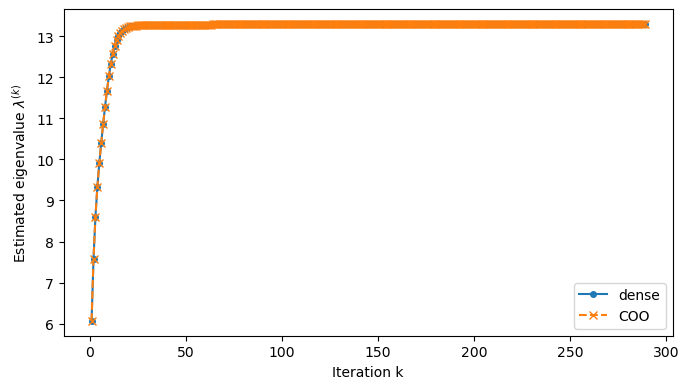

In [57]:
dense_k = np.arange(1, len(dense_power["eigenvalues"]) + 1)
coo_k = np.arange(1, len(coo_power["eigenvalues"]) + 1)

fig, ax = plt.subplots(figsize = (7, 4))

ax.plot(dense_k, dense_power["eigenvalues"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_power["eigenvalues"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

ax.set_xlabel("Iteration k")
ax.set_ylabel(r"Estimated eigenvalue $\lambda^{(k)}$")
ax.legend()

plt.tight_layout()
plt.show()

And the sparse method is similarly faster.

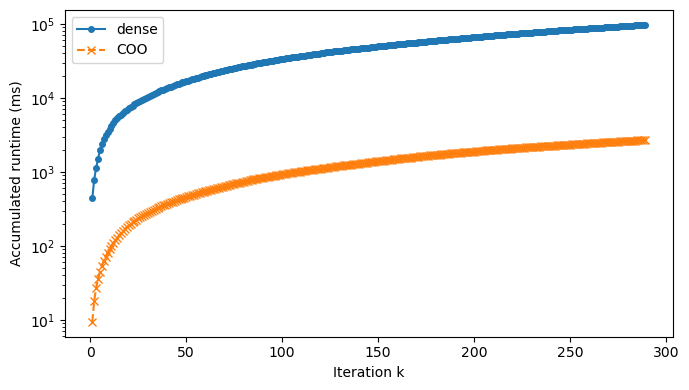

In [58]:
fig, ax = plt.subplots(figsize = (7, 4))

ax.plot(dense_k, dense_power["times"], label = "dense", marker = "o", markersize = 4)
ax.plot(coo_k, coo_power["times"], label = "COO", marker = "x", markersize = 6, linestyle = "--")

ax.set_yscale("log")
ax.set_xlabel("Iteration k")
ax.set_ylabel("Accumulated runtime (ms)")
ax.legend()

plt.tight_layout()
plt.show()

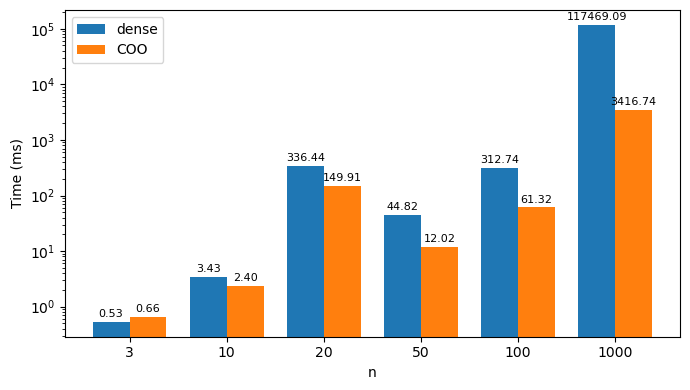

In [59]:
matricies.scaling_power(testcases, error = False, runs = 5)

The eigenvalue estimate climbs steeply for the first few iterations and then flattens onto its final value, which is the $|\lambda_2/\lambda_1|^k$ decay.

The iteration count is the interesting difference from Jacobi. It is not fixed by the construction of $A$, it is set by the gap between the two largest eigenvalues of whatever matrix got drawn, and that gap varies greatly between matricies of the same size and sparsity; you can see this reflected in the last plot where the power method for the randomly generated $A_{20}$ takes longer than the matrix five times its size, $A_{50}$. Rerunning this notebook has given me anywhere from 50 to 300 iterations for the same $N$ and the same construction, whereas for Jacobi the rate is a property of $D^{-1}R$, which, by our construction, will be similar across matricies.

Per-iteration cost lands at about half of Jacobi's, which is the two-products-per-iteration point from earlier turning up in the measurements. I expected the direction but not how cleanly the factor of two came out.

These timings include the COO conversion at each step, unlike the per-iteration numbers earlier. Jacobi behaves as expected: dense and COO are within noise of each other at $N = 3$ and separate steadily after that. Final errors are identical for both, as they have to be.